<a href="https://colab.research.google.com/github/derVian/datascience/blob/main/DatascienceInternshipARIMASARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf


In [ ]:
winter_df= pd.read_csv('/content/drive/MyDrive/Colab_Data/dfp2_winter_daytime_daily.csv')
spring_df=pd.read_csv('/content/drive/MyDrive/Colab_Data/dfp2_spring_daytime_daily.csv')
summer_df=pd.read_csv('/content/drive/MyDrive/Colab_Data/dfp2_summer_daytime_daily.csv')
autumn_df=pd.read_csv('/content/drive/MyDrive/Colab_Data/dfp2_autumn_daytime_daily.csv')
print(winter_df.head())
print(summer_df.head())
print(spring_df.head())
print(autumn_df.head())

         Date   GHI
0  2021-12-21   890
1  2021-12-22   638
2  2021-12-23   993
3  2021-12-24  1732
4  2021-12-25  2307
         Date   GHI
0  2022-06-21  7554
1  2022-06-22  4121
2  2022-06-23  4482
3  2022-06-24  7994
4  2022-06-25  4260
         Date   GHI
0  2022-03-20  2523
1  2022-03-21  3266
2  2022-03-22  2110
3  2022-03-23  3667
4  2022-03-24  1463
         Date   GHI
0  2022-09-22  3834
1  2022-09-23  4886
2  2022-09-24  4651
3  2022-09-25  3867
4  2022-09-26  5524


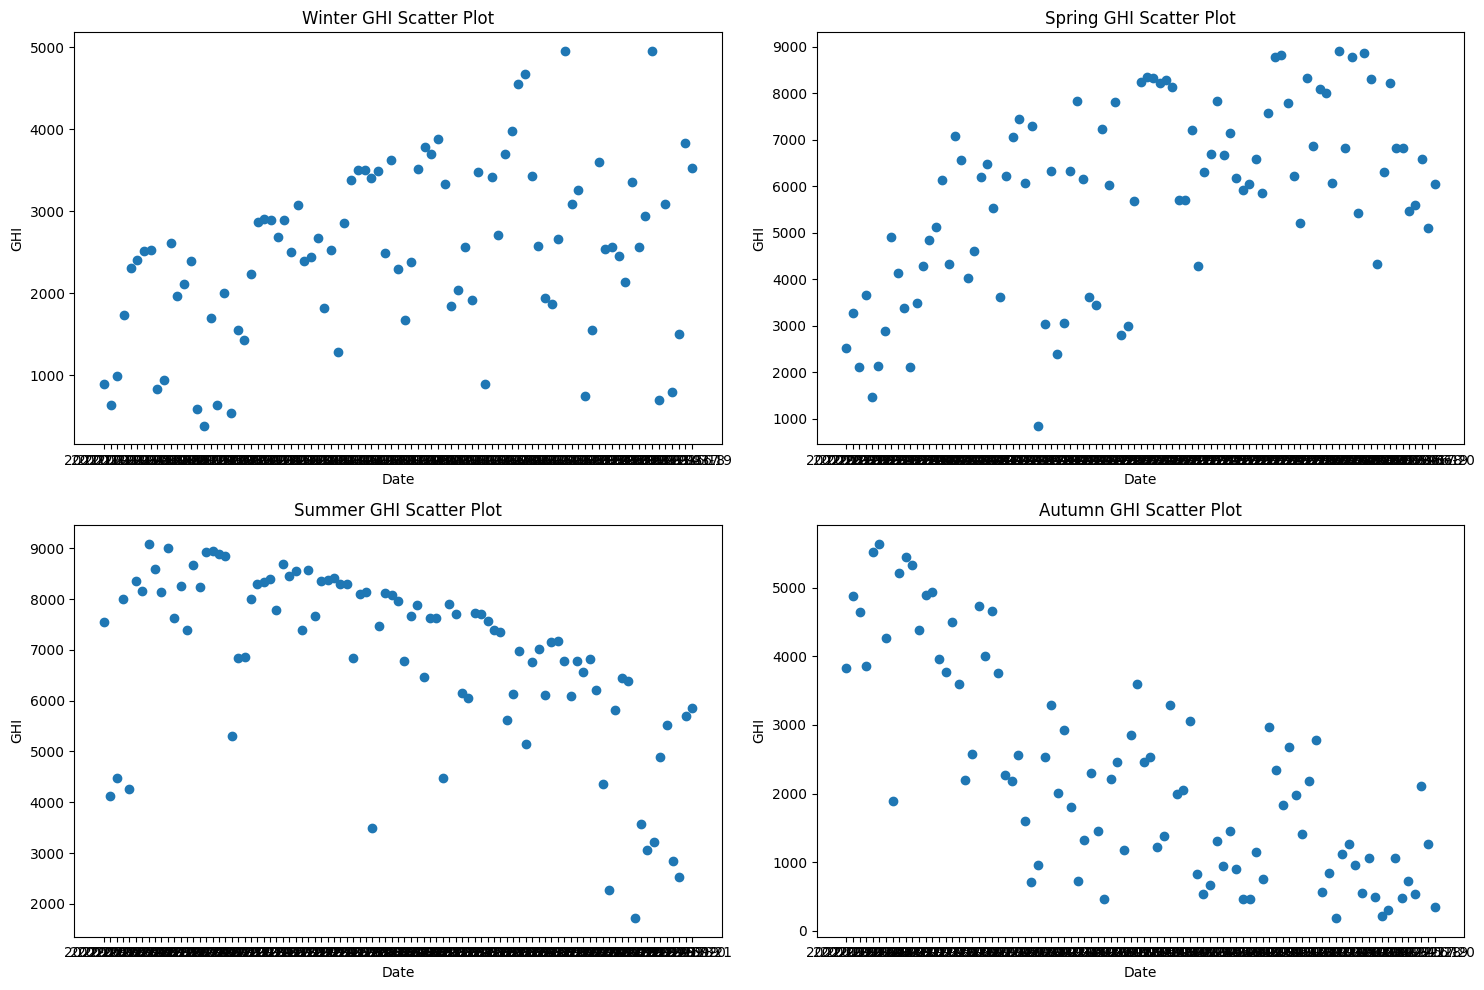

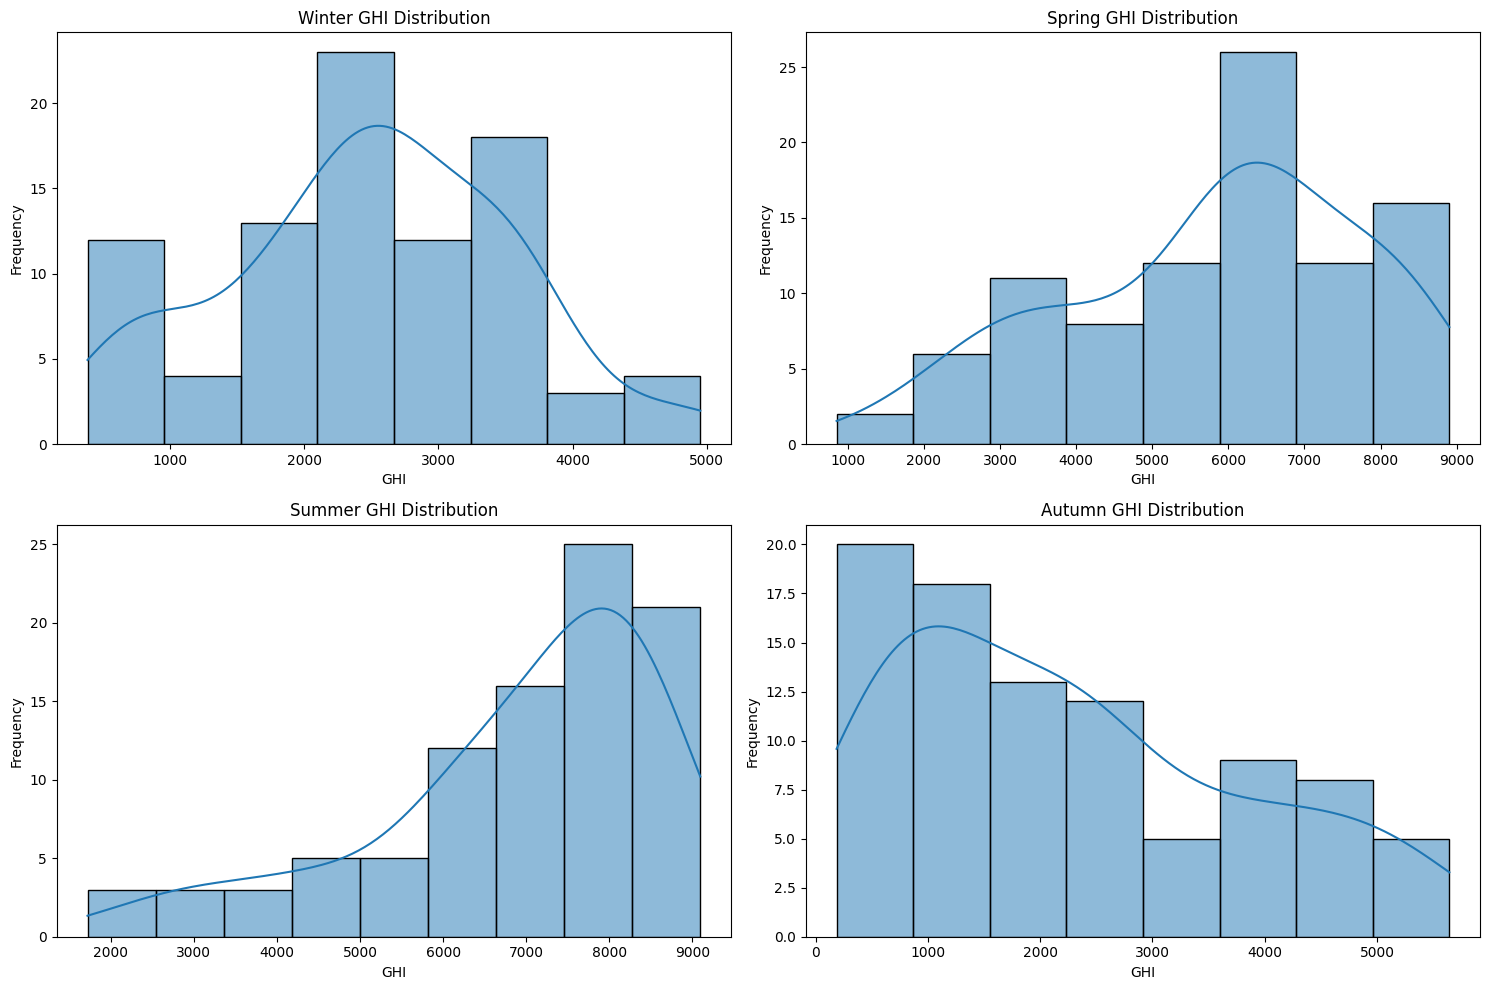

In [ ]:


# Scatter plots for each season
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.scatter(winter_df['Date'], winter_df['GHI'])
plt.title('Winter GHI Scatter Plot')
plt.xlabel('Date')
plt.ylabel('GHI')

plt.subplot(2, 2, 2)
plt.scatter(spring_df['Date'], spring_df['GHI'])
plt.title('Spring GHI Scatter Plot')
plt.xlabel('Date')
plt.ylabel('GHI')

plt.subplot(2, 2, 3)
plt.scatter(summer_df['Date'], summer_df['GHI'])
plt.title('Summer GHI Scatter Plot')
plt.xlabel('Date')
plt.ylabel('GHI')

plt.subplot(2, 2, 4)
plt.scatter(autumn_df['Date'], autumn_df['GHI'])
plt.title('Autumn GHI Scatter Plot')
plt.xlabel('Date')
plt.ylabel('GHI')

plt.tight_layout()
plt.show()

# Distribution plots for each season
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(winter_df['GHI'], kde=True)
plt.title('Winter GHI Distribution')
plt.xlabel('GHI')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(spring_df['GHI'], kde=True)
plt.title('Spring GHI Distribution')
plt.xlabel('GHI')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.histplot(summer_df['GHI'], kde=True)
plt.title('Summer GHI Distribution')
plt.xlabel('GHI')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.histplot(autumn_df['GHI'], kde=True)
plt.title('Autumn GHI Distribution')
plt.xlabel('GHI')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<Axes: >

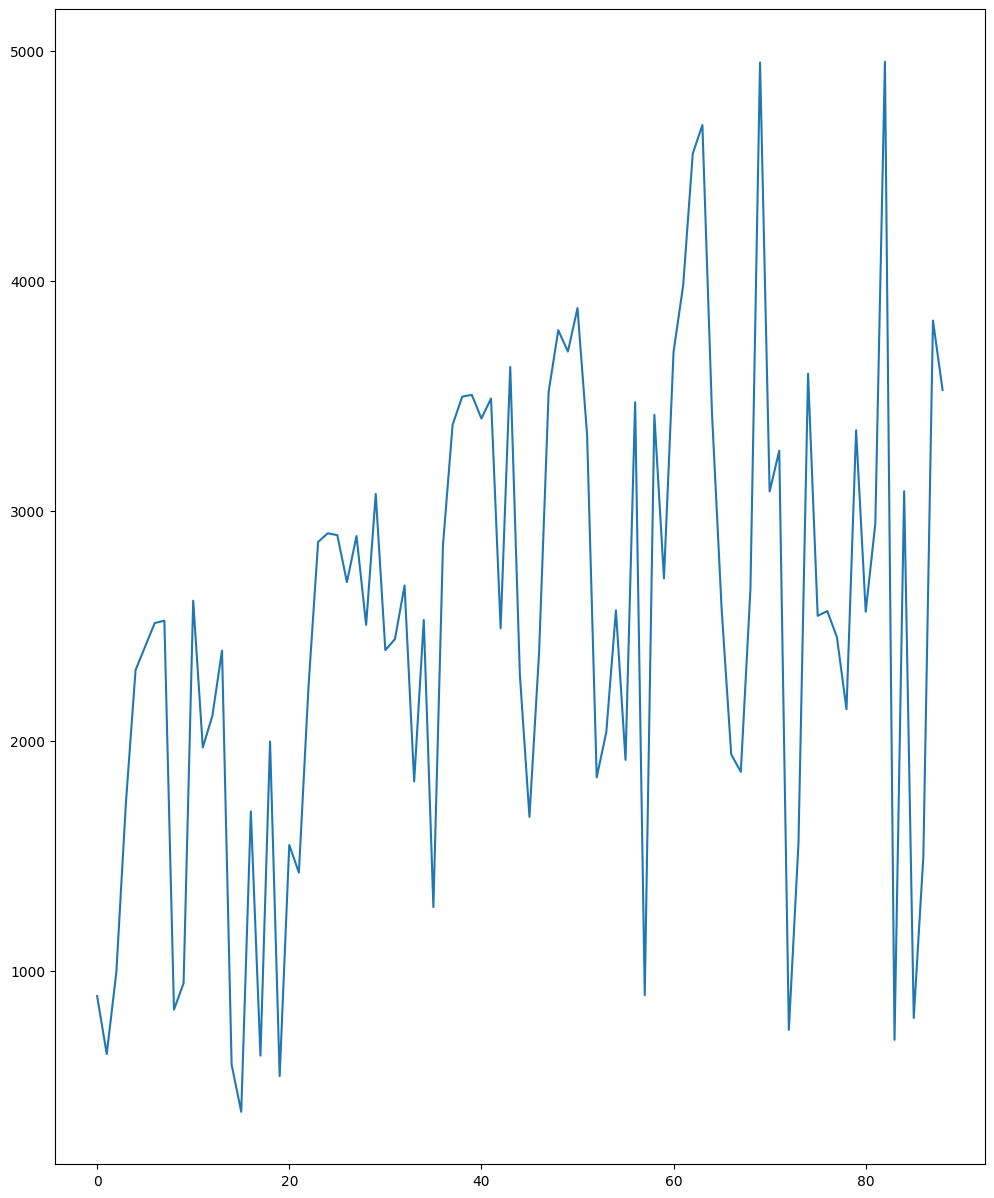

In [8]:
winter_df['GHI'].plot(figsize=(12,15))

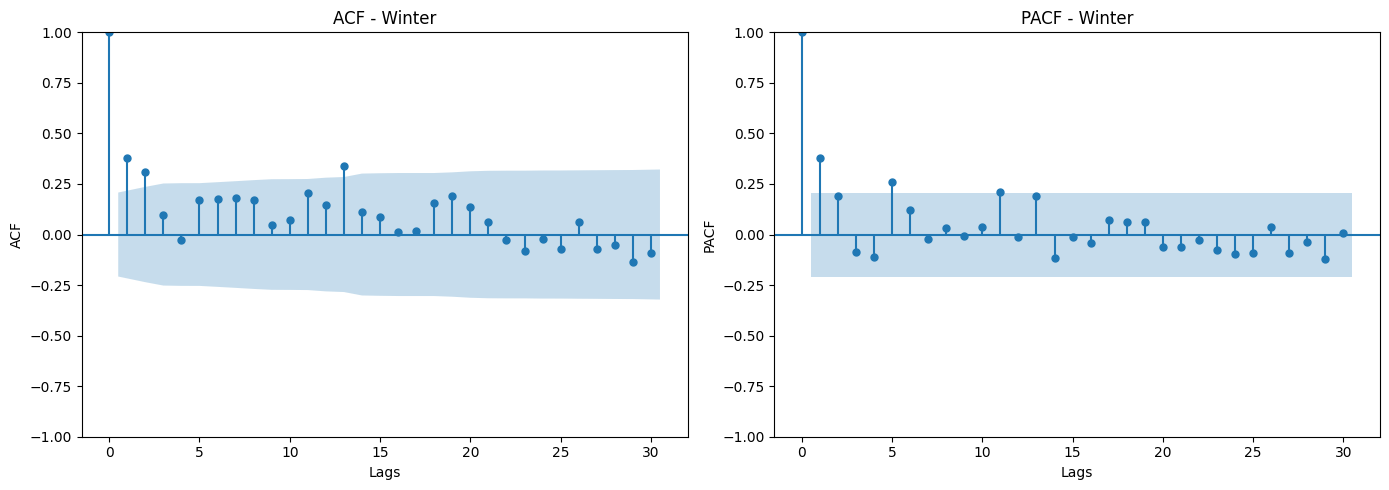

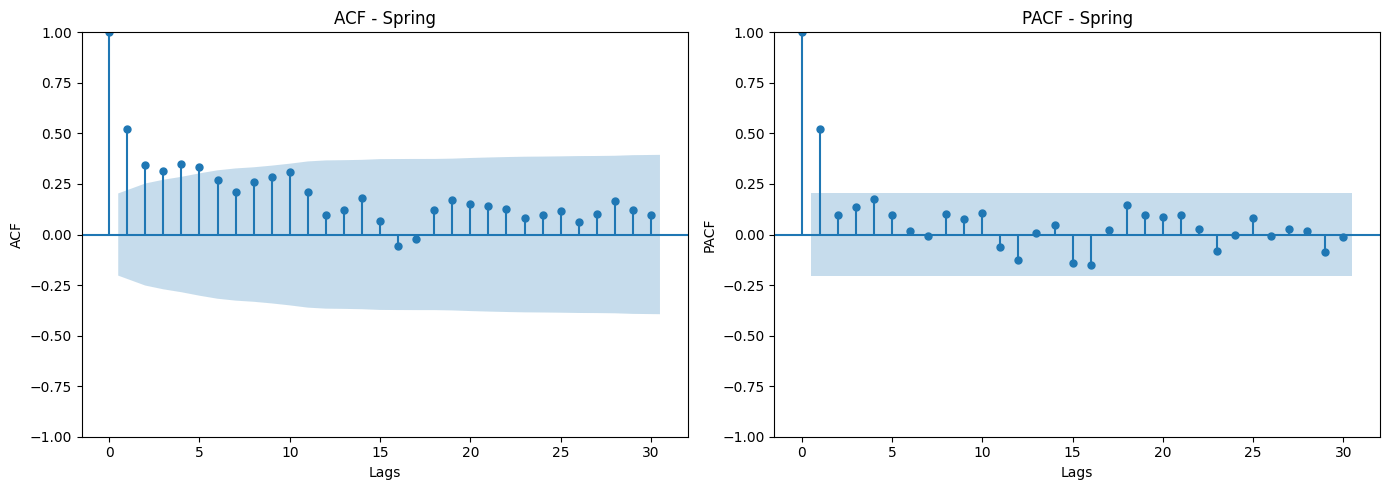

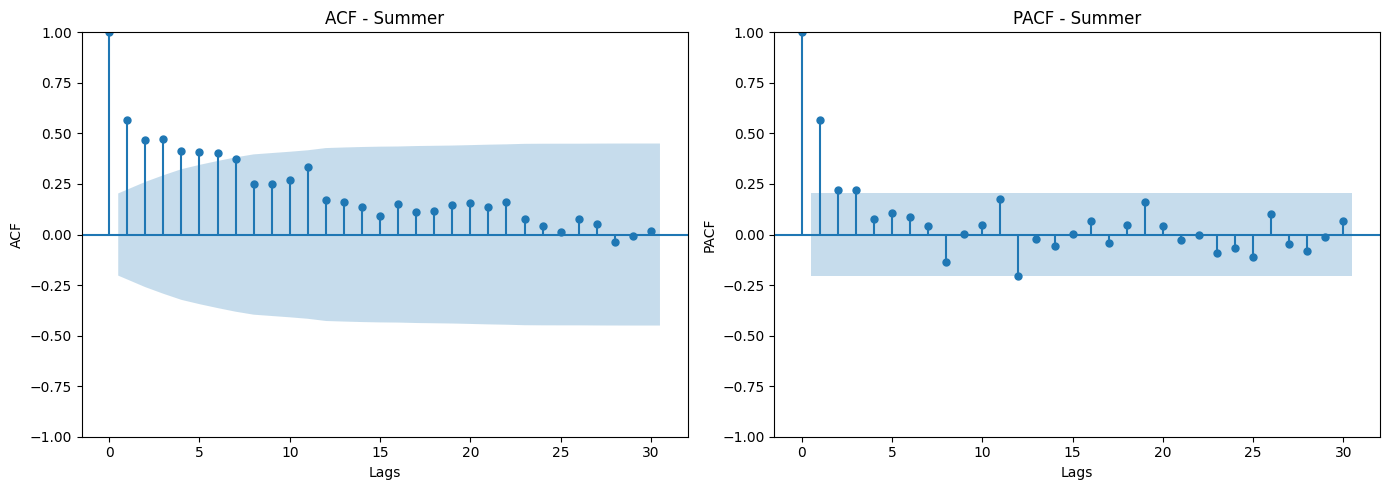

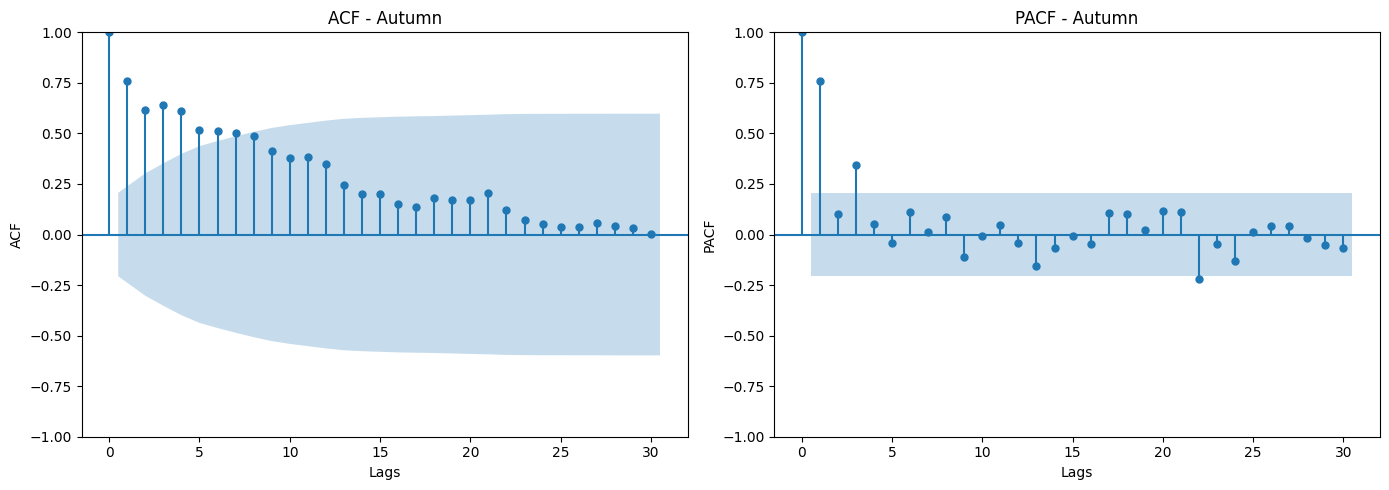

In [78]:
seasonal_dfs = {'Winter': winter_df, 'Spring': spring_df, 'Summer': summer_df, 'Autumn': autumn_df}

for season_name, df in seasonal_dfs.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_acf(df['GHI'], lags=30, ax=axes[0])
    axes[0].set_title(f'ACF - {season_name}')
    axes[0].set_xlabel('Lags')
    axes[0].set_ylabel('ACF')

    plot_pacf(df['GHI'], lags=30, ax=axes[1])
    axes[1].set_title(f'PACF - {season_name}')
    axes[1].set_xlabel('Lags')
    axes[1].set_ylabel('PACF')

    plt.tight_layout()
    plt.show()

In [36]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Convert 'Date' to datetime and set as index for winter_df
winter_df['Date'] = pd.to_datetime(winter_df['Date'])
winter_df = winter_df.set_index('Date')
winter_df = winter_df.sort_index()

# Convert 'Date' to datetime and set as index for spring_df
spring_df['Date'] = pd.to_datetime(spring_df['Date'])
spring_df = spring_df.set_index('Date')
spring_df = spring_df.sort_index()

# Convert 'Date' to datetime and set as index for summer_df
summer_df['Date'] = pd.to_datetime(summer_df['Date'])
summer_df = summer_df.set_index('Date')
summer_df = summer_df.sort_index()

# Convert 'Date' to datetime and set as index for autumn_df
autumn_df['Date'] = pd.to_datetime(autumn_df['Date'])
autumn_df = autumn_df.set_index('Date')
autumn_df = autumn_df.sort_index()

print("Libraries imported and 'Date' column processed for all dataframes.")
print(winter_df.head())
print(spring_df.head())
print(summer_df.head())
print(autumn_df.head())

KeyError: 'Date'

### MAE and RMSE Comparison Plots

In [59]:
from math import sqrt

def evaluate_and_plot_model(df, name="Season"):
    # Split data into training and testing sets
    train_size = int(len(df) * 0.8)
    train, test = df.iloc[:train_size], df.iloc[train_size:]

    # ARIMA Model
    # Initial order (p,d,q) can be chosen based on ACF/PACF or domain knowledge
    # Using (5,1,0) as a common starting point for non-seasonal component
    try:
        arima_model = ARIMA(train['GHI'], order=(2, 0, 1))
        arima_model_fit = arima_model.fit()
        arima_predictions = arima_model_fit.predict(start=len(train), end=len(df)-1)

        # Calculate ARIMA metrics
        arima_aic = arima_model_fit.aic
        arima_bic = arima_model_fit.bic
        arima_mae = mean_absolute_error(test['GHI'], arima_predictions)
        arima_rmse = sqrt(mean_squared_error(test['GHI'], arima_predictions))

        # Plot ARIMA results
        plt.figure(figsize=(14, 6))
        plt.plot(test['GHI'].index, test['GHI'], label='Actual GHI')
        plt.plot(arima_predictions.index, arima_predictions, color='red', label='ARIMA Predicted GHI')
        plt.title(f'ARIMA Model: Actual vs. Predicted GHI for {name}')
        plt.xlabel('Date')
        plt.ylabel('GHI')
        plt.legend()
        plt.show()

        plt.figure(figsize=(14, 6))
        arima_residuals = test['GHI'] - arima_predictions
        plt.plot(arima_residuals.index, arima_residuals, label='ARIMA Residuals')
        plt.axhline(0, color='gray', linestyle='--')
        plt.title(f'ARIMA Model: Residuals Plot for {name}')
        plt.xlabel('Date')
        plt.ylabel('Residual')
        plt.legend()
        plt.show()

        print(f"ARIMA Model Metrics for {name}:")
        print(f"  AIC: {arima_aic:.2f}")
        print(f"  BIC: {arima_bic:.2f}")
        print(f"  MAE: {arima_mae:.2f}")
        print(f"  RMSE: {arima_rmse:.2f}")
    except Exception as e:
        print(f"ARIMA model for {name} failed: {e}")
        arima_aic, arima_bic, arima_mae, arima_rmse = np.nan, np.nan, np.nan, np.nan

    print("\n" + "-"*30 + "\n")

    # SARIMA Model
    # Initial order (p,d,q) and seasonal order (P,D,Q,S)
    try:
        sarima_model = SARIMAX(train['GHI'], order=(2, 0, 1), seasonal_order=(1, 0, 0, 7))
        sarima_model_fit = sarima_model.fit(disp=False)
        sarima_predictions = sarima_model_fit.predict(start=len(train), end=len(df)-1)

        # Calculate SARIMA metrics
        sarima_aic = sarima_model_fit.aic
        sarima_bic = sarima_model_fit.bic
        sarima_mae = mean_absolute_error(test['GHI'], sarima_predictions)
        sarima_rmse = sqrt(mean_squared_error(test['GHI'], sarima_predictions))

        # Plot SARIMA results
        plt.figure(figsize=(14, 6))
        plt.plot(test['GHI'].index, test['GHI'], label='Actual GHI')
        plt.plot(sarima_predictions.index, sarima_predictions, color='green', label='SARIMA Predicted GHI')
        plt.title(f'SARIMA Model: Actual vs. Predicted GHI for {name}')
        plt.xlabel('Date')
        plt.ylabel('GHI')
        plt.legend()
        plt.show()

        plt.figure(figsize=(14, 6))
        sarima_residuals = test['GHI'] - sarima_predictions
        plt.plot(sarima_residuals.index, sarima_residuals, label='SARIMA Residuals')
        plt.axhline(0, color='gray', linestyle='--')
        plt.title(f'SARIMA Model: Residuals Plot for {name}')
        plt.xlabel('Date')
        plt.ylabel('Residual')
        plt.legend()
        plt.show()

        print(f"SARIMA Model Metrics for {name}:")
        print(f"  AIC: {sarima_aic:.2f}")
        print(f"  BIC: {sarima_bic:.2f}")
        print(f"  MAE: {sarima_mae:.2f}")
        print(f"  RMSE: {sarima_rmse:.2f}")
    except Exception as e:
        print(f"SARIMA model for {name} failed: {e}")
        sarima_aic, sarima_bic, sarima_mae, sarima_rmse = np.nan, np.nan, np.nan, np.nan

    return {
        'ARIMA_AIC': arima_aic,
        'ARIMA_BIC': arima_bic,
        'ARIMA_MAE': arima_mae,
        'ARIMA_RMSE': arima_rmse,
        'SARIMA_AIC': sarima_aic,
        'SARIMA_BIC': sarima_bic,
        'SARIMA_MAE': sarima_mae,
        'SARIMA_RMSE': sarima_rmse
    }


--- Evaluating Winter Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


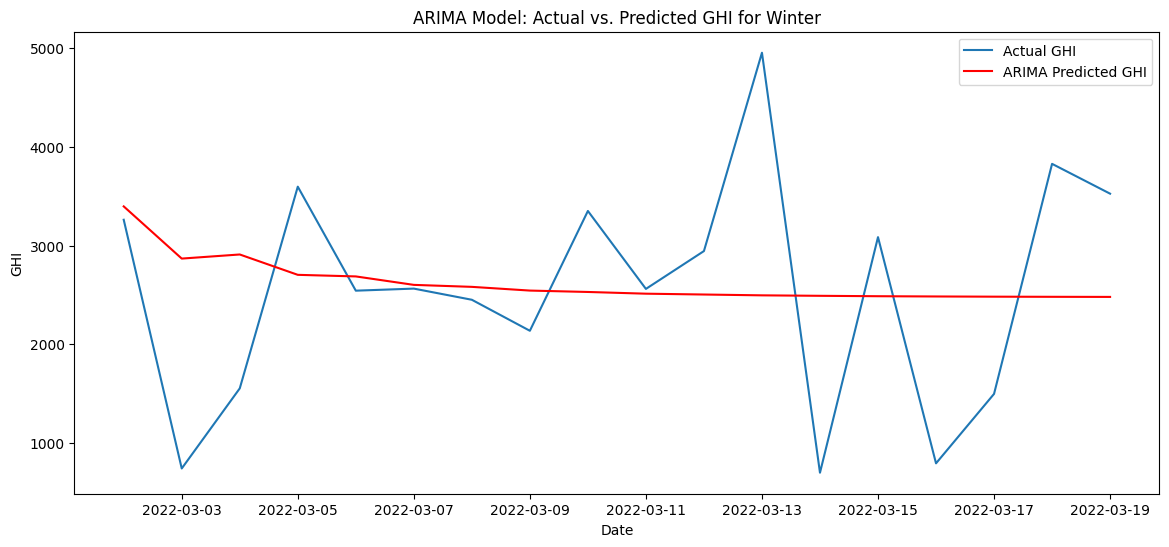

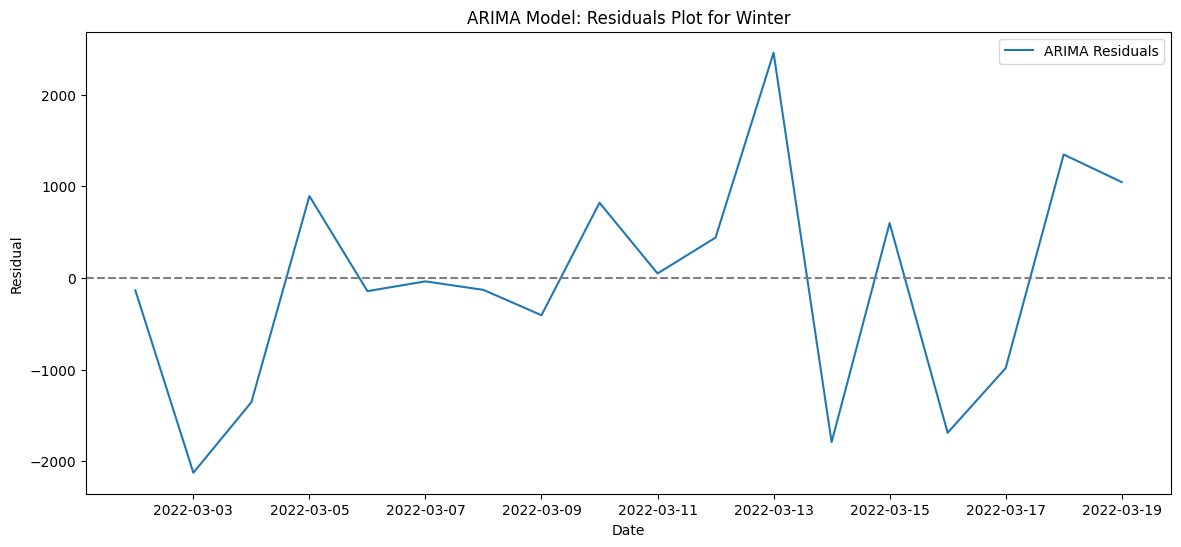

ARIMA Model Metrics for Winter:
  AIC: 1165.99
  BIC: 1177.30
  MAE: 913.70
  RMSE: 1168.25

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


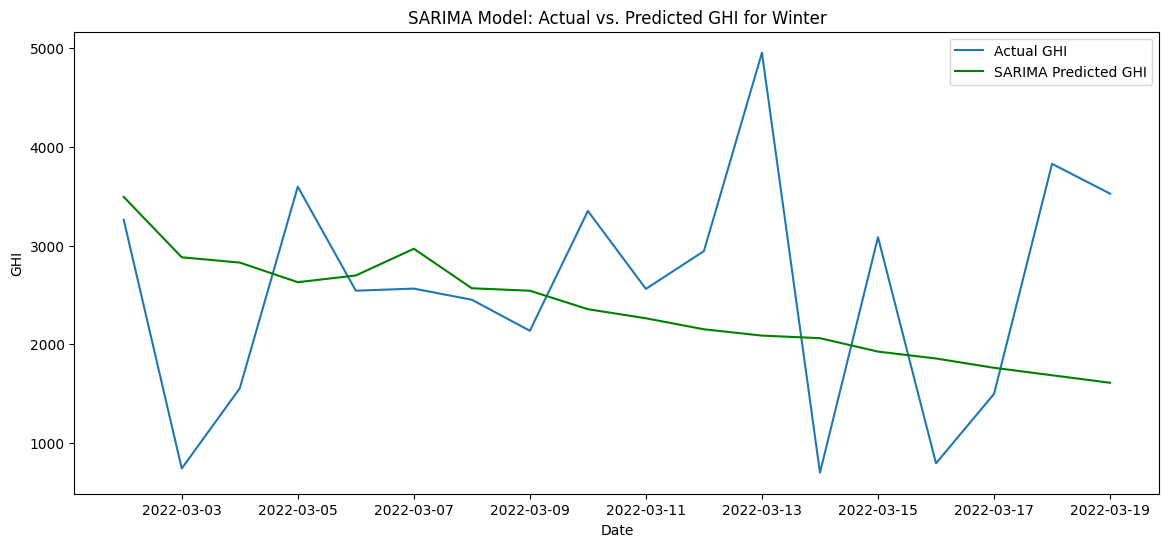

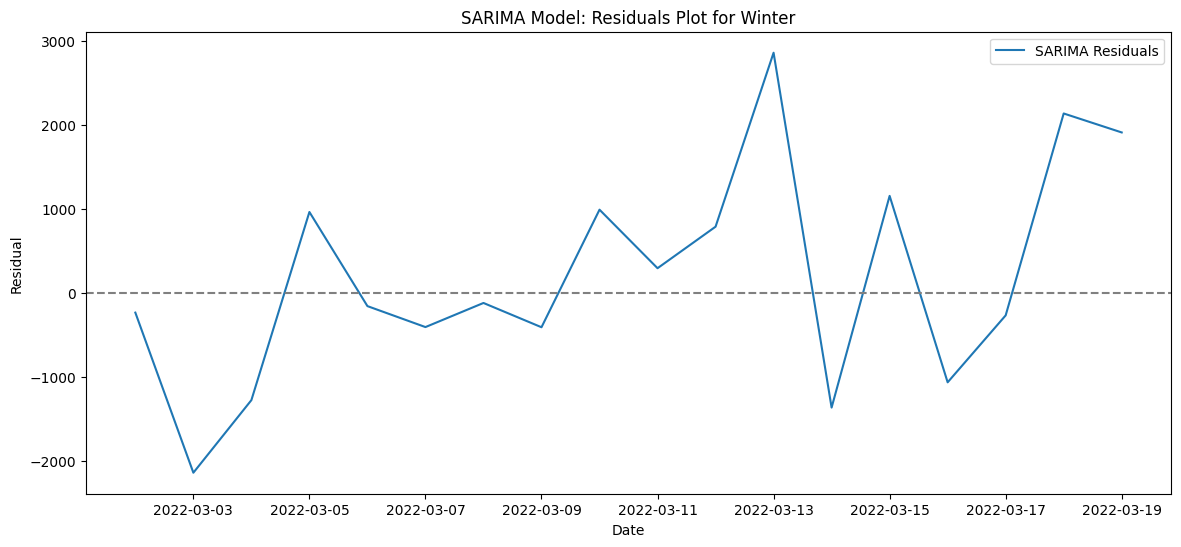

SARIMA Model Metrics for Winter:
  AIC: 1174.08
  BIC: 1185.40
  MAE: 1029.89
  RMSE: 1292.97

--- Evaluating Spring Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

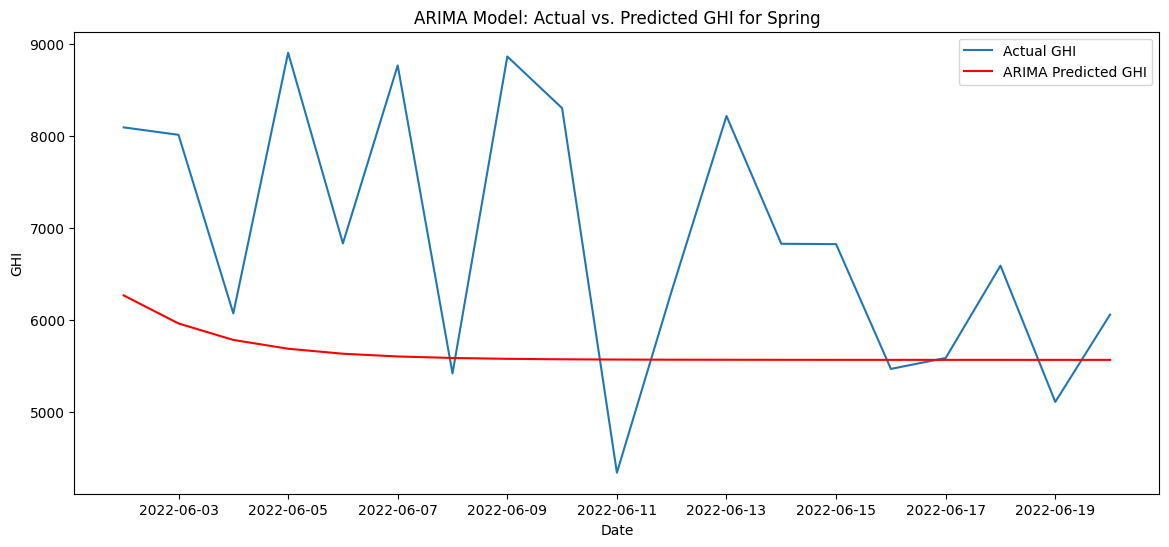

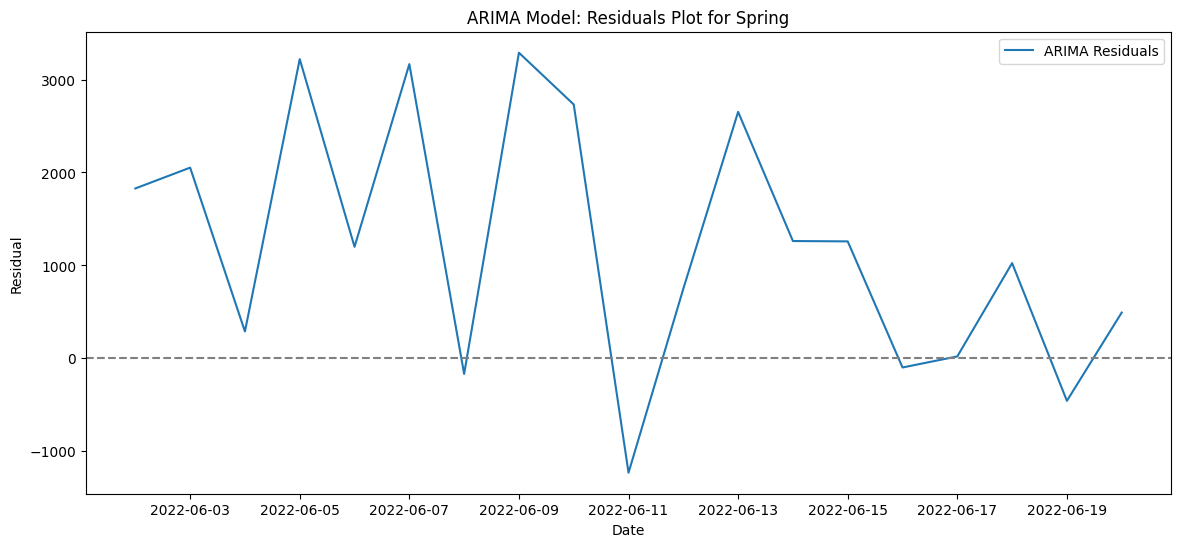

ARIMA Model Metrics for Spring:
  AIC: 1317.62
  BIC: 1329.14
  MAE: 1430.84
  RMSE: 1799.92

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimiz

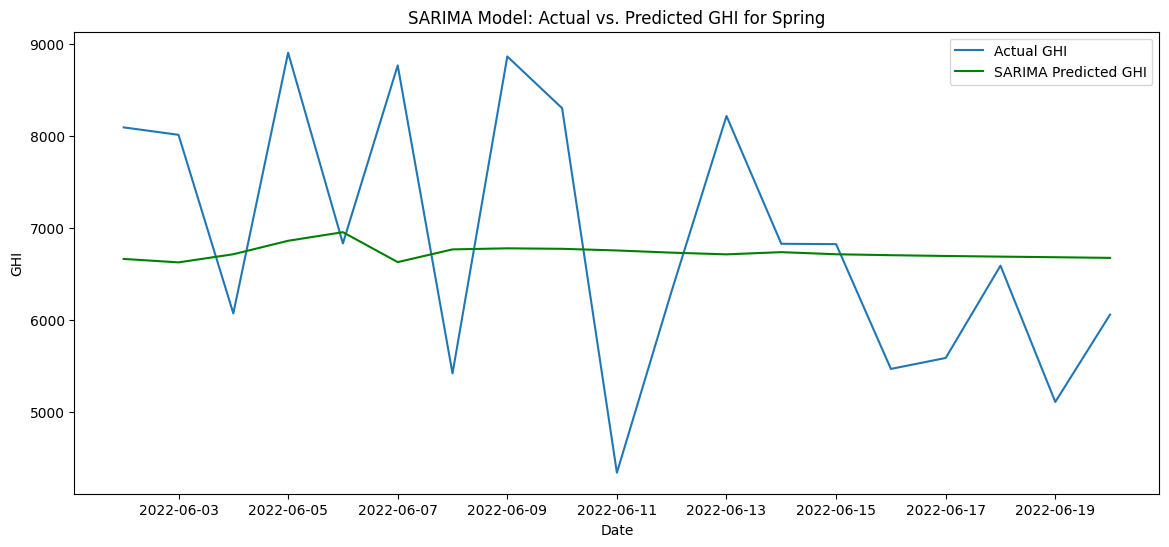

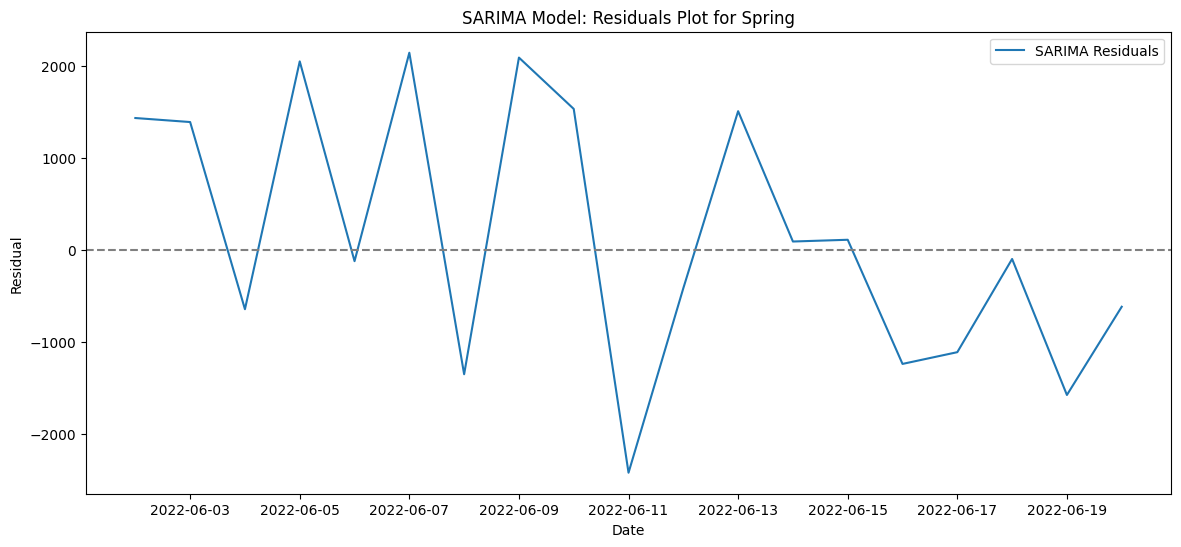

SARIMA Model Metrics for Spring:
  AIC: 1315.92
  BIC: 1327.44
  MAE: 1153.01
  RMSE: 1368.87

--- Evaluating Summer Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

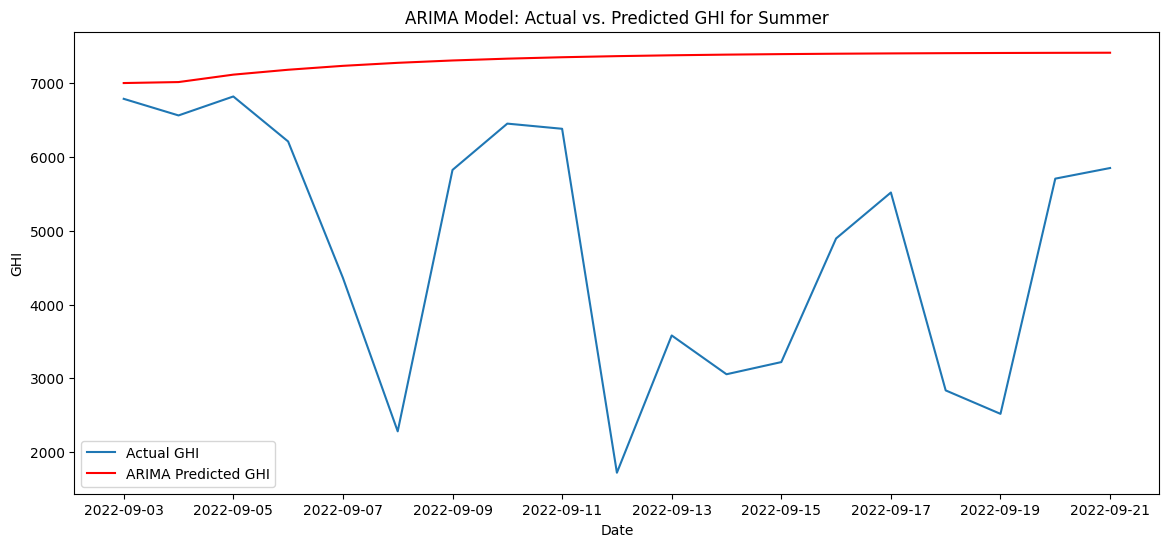

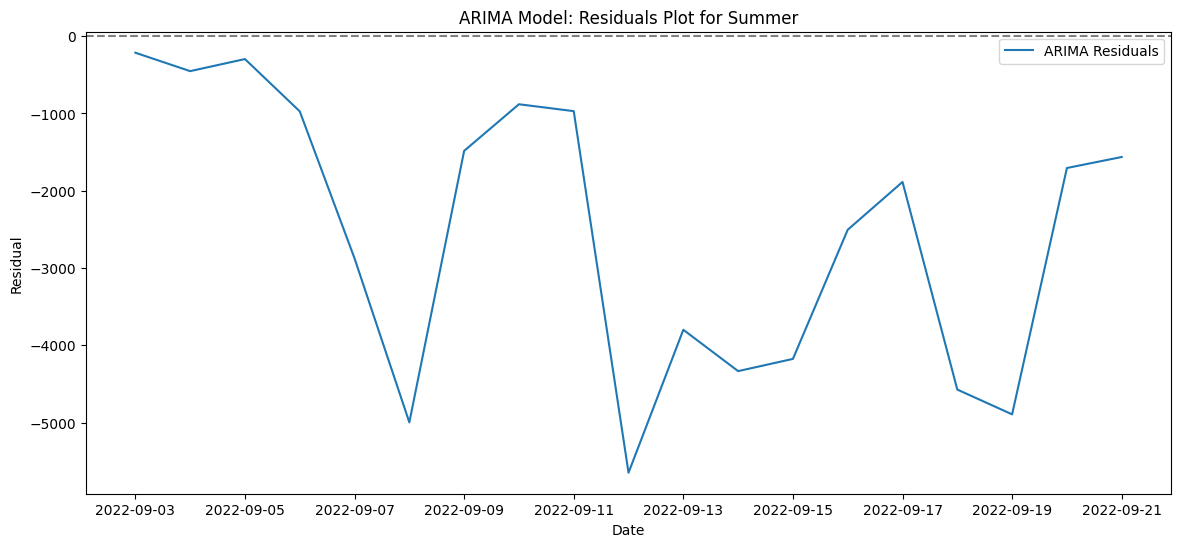

ARIMA Model Metrics for Summer:
  AIC: 1266.51
  BIC: 1278.03
  MAE: 2537.83
  RMSE: 3086.36

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


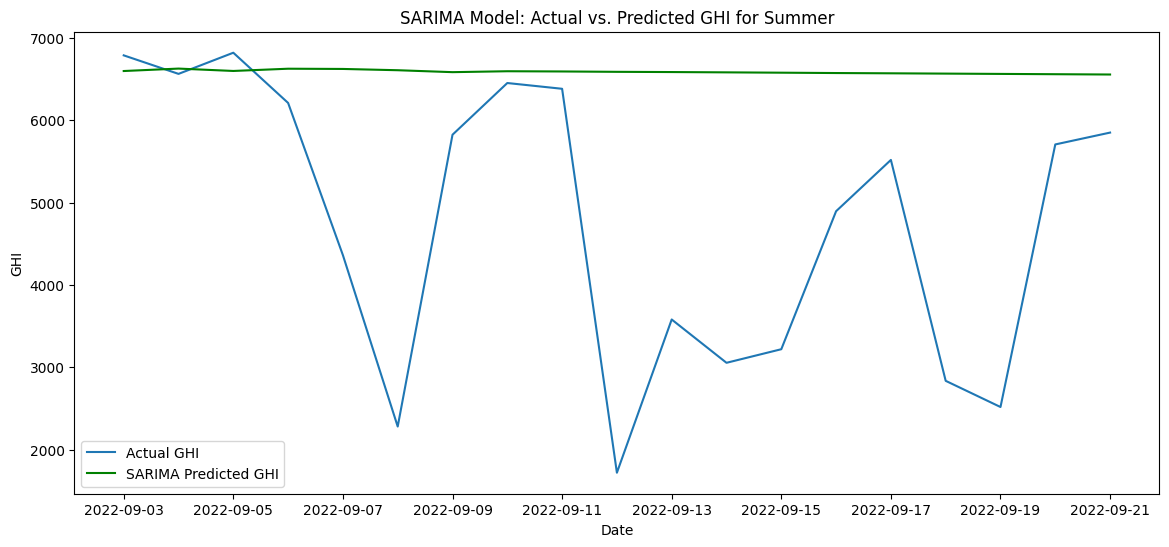

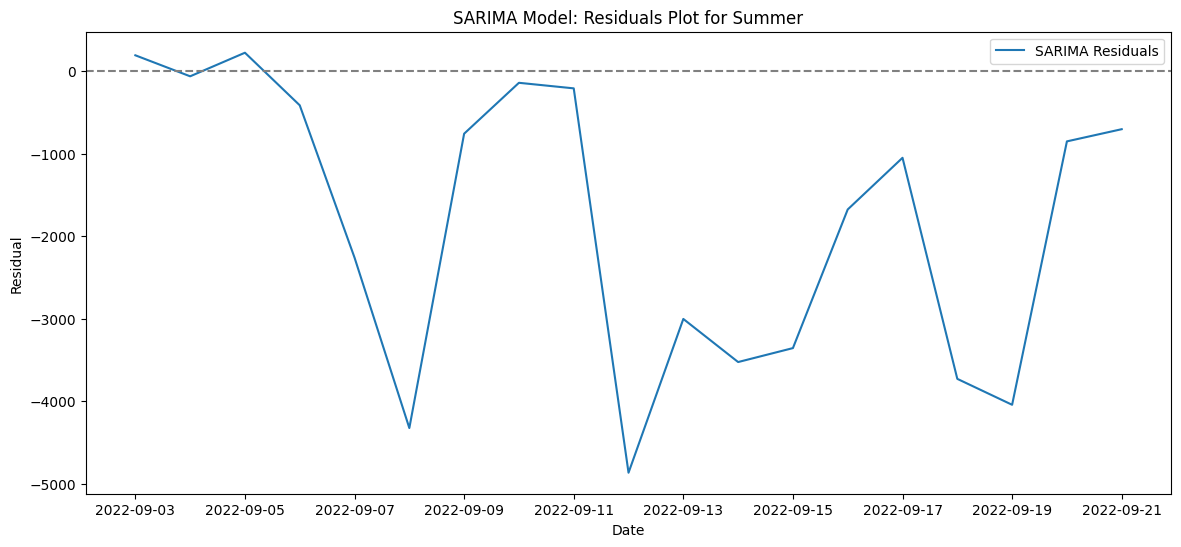

SARIMA Model Metrics for Summer:
  AIC: 1274.21
  BIC: 1285.73
  MAE: 1864.23
  RMSE: 2477.76

--- Evaluating Autumn Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

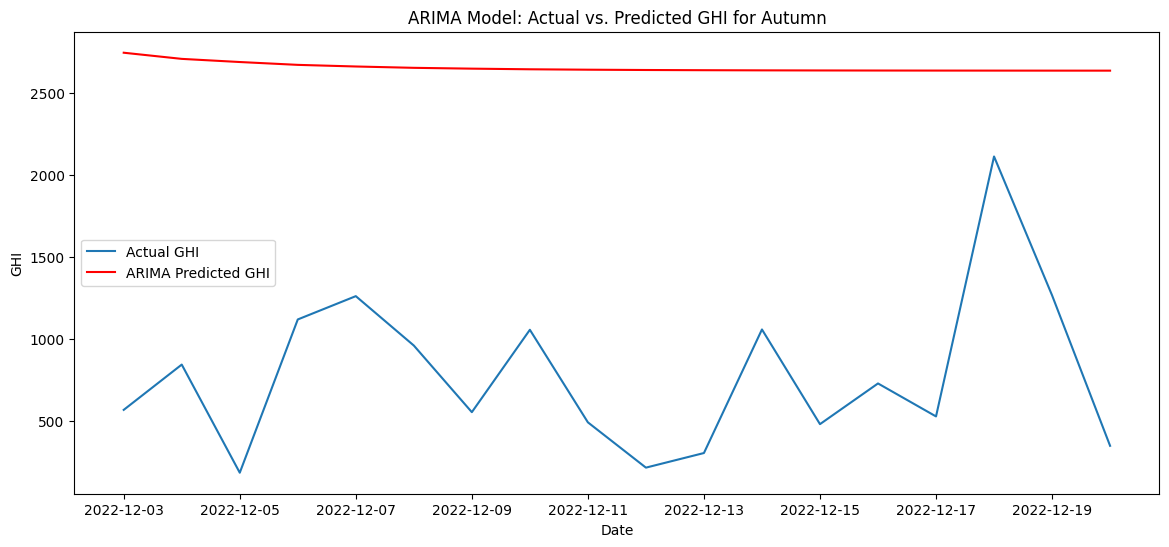

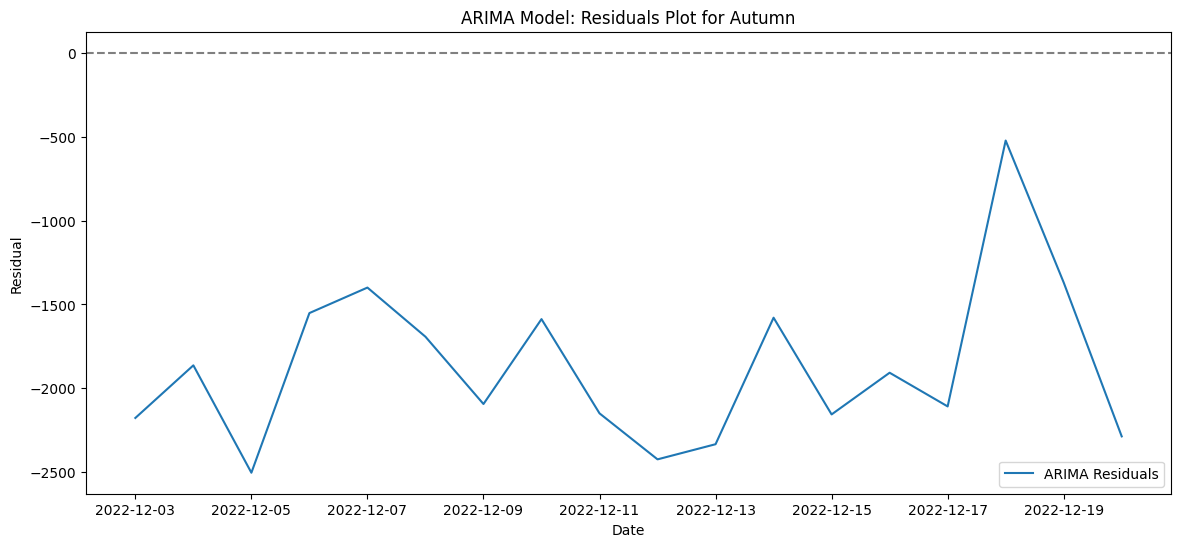

ARIMA Model Metrics for Autumn:
  AIC: 1209.21
  BIC: 1220.60
  MAE: 1872.08
  RMSE: 1931.06

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


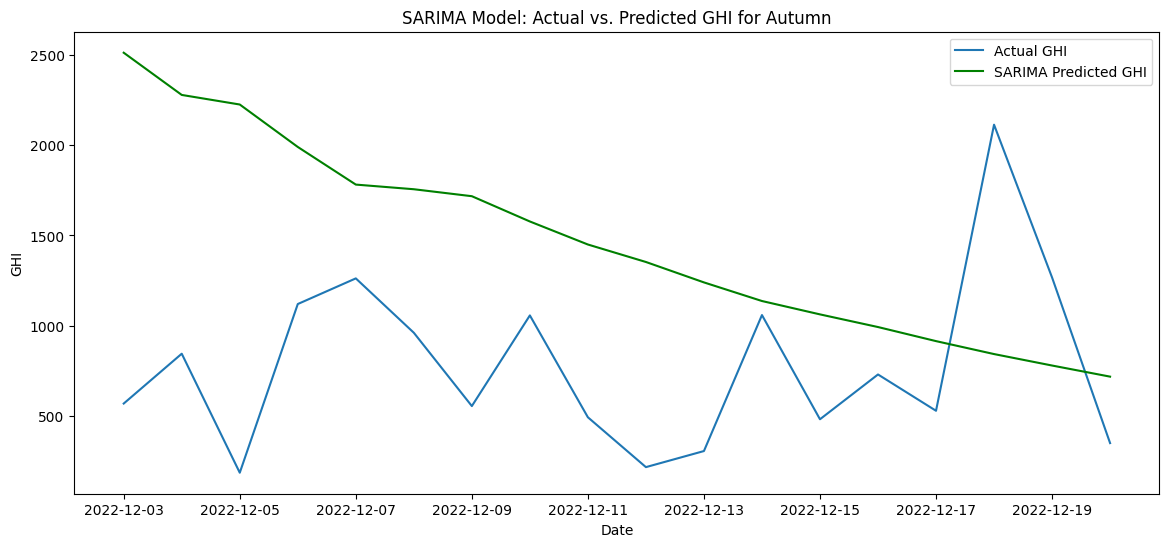

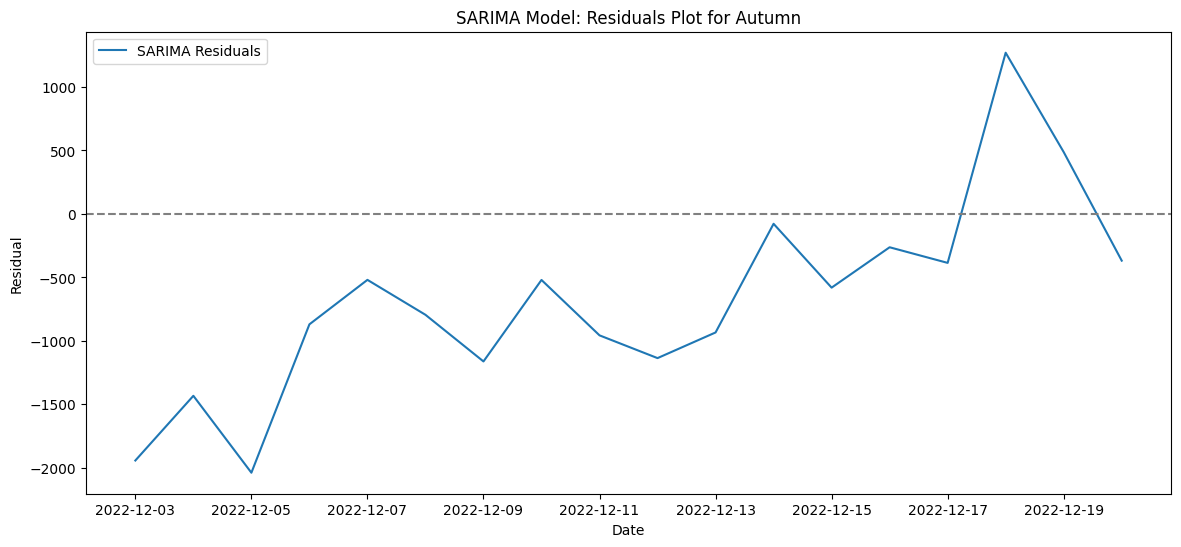

SARIMA Model Metrics for Autumn:
  AIC: 1219.10
  BIC: 1230.49
  MAE: 874.35
  RMSE: 1024.30

--- Summary of Model Metrics ---
Winter Metrics: {'ARIMA_AIC': np.float64(1165.9857519650545), 'ARIMA_BIC': np.float64(1177.2991513502611), 'ARIMA_MAE': 913.6953031891628, 'ARIMA_RMSE': 1168.2467549819294, 'SARIMA_AIC': np.float64(1174.0823079498653), 'SARIMA_BIC': np.float64(1185.3957073350718), 'SARIMA_MAE': 1029.8923040953557, 'SARIMA_RMSE': 1292.9714467238116}
Spring Metrics: {'ARIMA_AIC': np.float64(1317.61602711898), 'ARIMA_BIC': np.float64(1329.1363525850009), 'ARIMA_MAE': 1430.8362348580442, 'ARIMA_RMSE': 1799.9160478820856, 'SARIMA_AIC': np.float64(1315.9231414461638), 'SARIMA_BIC': np.float64(1327.4434669121847), 'SARIMA_MAE': 1153.0107770042803, 'SARIMA_RMSE': 1368.8680808745266}
Summer Metrics: {'ARIMA_AIC': np.float64(1266.5119135489776), 'ARIMA_BIC': np.float64(1278.0322390149986), 'ARIMA_MAE': 2537.8339060769677, 'ARIMA_RMSE': 3086.3643780211783, 'SARIMA_AIC': np.float64(1274.20

In [60]:
print("\n--- Evaluating Winter Data ---")
winter_metrics = evaluate_and_plot_model(winter_df, name="Winter")

print("\n--- Evaluating Spring Data ---")
spring_metrics = evaluate_and_plot_model(spring_df, name="Spring")

print("\n--- Evaluating Summer Data ---")
summer_metrics = evaluate_and_plot_model(summer_df, name="Summer")

print("\n--- Evaluating Autumn Data ---")
autumn_metrics = evaluate_and_plot_model(autumn_df, name="Autumn")

print("\n--- Summary of Model Metrics ---")
print("Winter Metrics:", winter_metrics)
print("Spring Metrics:", spring_metrics)
print("Summer Metrics:", summer_metrics)
print("Autumn Metrics:", autumn_metrics)

In [79]:
all_metrics = {
    'Winter': winter_metrics,
    'Spring': spring_metrics,
    'Summer': summer_metrics,
    'Autumn': autumn_metrics
}

metrics_df = pd.DataFrame(all_metrics)

print("\n--- Model Metrics Summary ---")
print(metrics_df)


--- Model Metrics Summary ---
                  Winter       Spring       Summer       Autumn
ARIMA_AIC    1165.985752  1317.616027  1266.511914  1209.214825
ARIMA_BIC    1177.299151  1329.136353  1278.032239  1220.598155
ARIMA_MAE     913.695303  1430.836235  2537.833906  1872.082321
ARIMA_RMSE   1168.246755  1799.916048  3086.364378  1931.061479
SARIMA_AIC   1174.082308  1315.923141  1274.205833  1219.102210
SARIMA_BIC   1185.395707  1327.443467  1285.726159  1230.485541
SARIMA_MAE   1029.892304  1153.010777  1864.225352   874.354986
SARIMA_RMSE  1292.971447  1368.868081  2477.757906  1024.297582


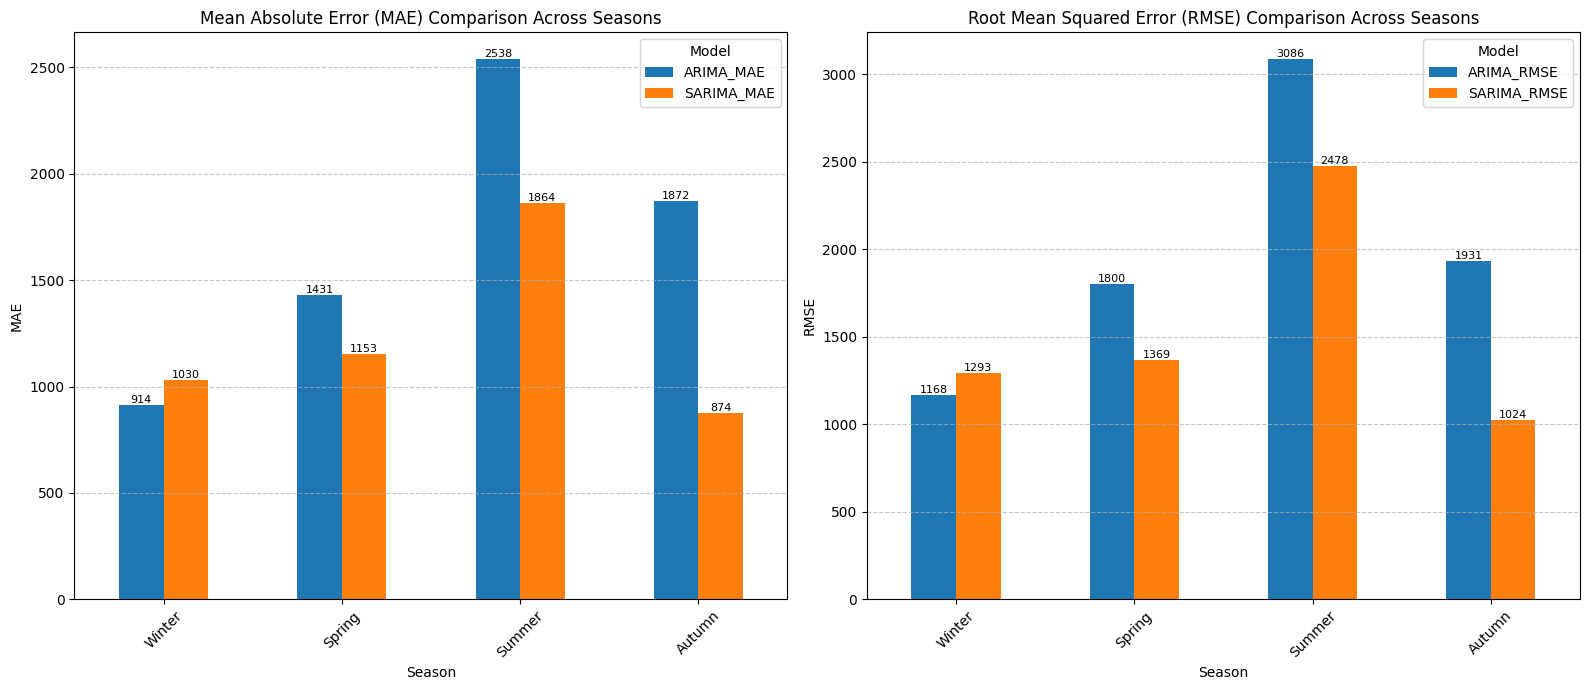

In [81]:


# Prepare data for plotting
metrics_to_plot = metrics_df.loc[['ARIMA_MAE', 'SARIMA_MAE', 'ARIMA_RMSE', 'SARIMA_RMSE']]
metrics_to_plot = metrics_to_plot.T # Transpose to have seasons as index

plt.figure(figsize=(16, 7))

# Plot MAE
plt.subplot(1, 2, 1)
ax_mae = metrics_to_plot[['ARIMA_MAE', 'SARIMA_MAE']].plot(kind='bar', ax=plt.gca())
plt.title('Mean Absolute Error (MAE) Comparison Across Seasons')
plt.xlabel('Season')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars for MAE
for container in ax_mae.containers:
    for i, bar in enumerate(container):
        ax_mae.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

# Plot RMSE
plt.subplot(1, 2, 2)
ax_rmse = metrics_to_plot[['ARIMA_RMSE', 'SARIMA_RMSE']].plot(kind='bar', ax=plt.gca())
plt.title('Root Mean Squared Error (RMSE) Comparison Across Seasons')
plt.xlabel('Season')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars for RMSE
for container in ax_rmse.containers:
    for i, bar in enumerate(container):
        ax_rmse.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()